<a href="https://colab.research.google.com/github/Keerthiga-I/PYTHON-CODE/blob/PYTHON-LEVELS/pra.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
df=pd.read_excel('/content/sales_sample_data (1).xlsx')

In [17]:
df

,Date,Product,Region,Sales_Rep,Units_Sold,Price_Per_Unit,Revenue,Cost,Profit,Customer_Rating
0,2023-01-01,Laptop,North,John Smith,12,999,11988,8400,3588,4.5
1,2023-01-02,Phone,South,Emma Davis,25,699,17475,12500,4975,4.2
2,2023-01-03,Tablet,East,Mike Johnson,18,499,8982,6300,2682,4.8
3,2023-01-04,Laptop,West,Sarah Wilson,15,999,14985,10500,4485,4.3
4,2023-02-01,Phone,North,John Smith,30,699,20970,15000,5970,4.6
5,2023-02-02,Tablet,South,Emma Davis,22,499,10978,7700,3278,4.1
6,2023-02-03,Laptop,East,Mike Johnson,10,999,9990,7000,2990,4.7
7,2023-02-04,Phone,West,Sarah Wilson,28,699,19572,14000,5572,4.4
8,2023-03-01,Tablet,North,John Smith,20,499,9980,7000,2980,4.2
9,2023-03-02,Laptop,South,Emma Davis,14,999,13986,9800,4186,4.5


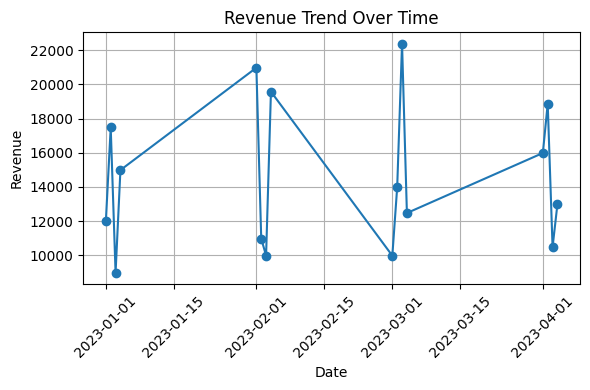

In [19]:
df_sorted=df.sort_values('Date')

plt.figure(figsize=(6,4))
plt.plot(df_sorted['Date'],df_sorted['Revenue'],marker='o')
plt.title("Revenue Trend Over Time")
plt.xlabel('Date')
plt.ylabel('Revenue')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Product Count Frequency:
 Product
Laptop    6
Phone     5
Tablet    5
Name: count, dtype: int64


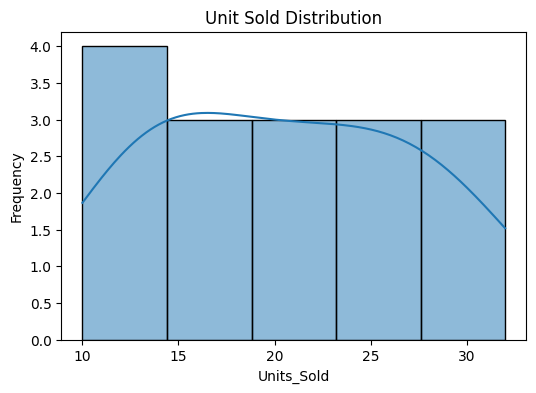

In [20]:
product_count=df['Product'].value_counts()
print('Product Count Frequency:\n',product_count)

plt.figure(figsize=(6,4))
sns.histplot(df['Units_Sold'],bins=5,kde=True)
plt.title("Unit Sold Distribution")
plt.xlabel('Units_Sold')
plt.ylabel('Frequency')
plt.show()

Rating Categories:
 Rating_category
Low       6
Medium    6
High      4
Name: count, dtype: int64


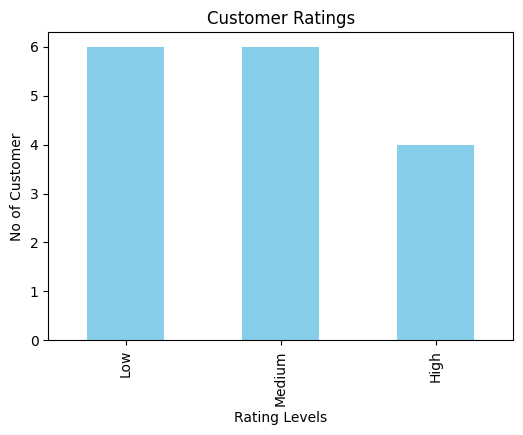

In [23]:
df['Rating_category']=pd.cut(df['Customer_Rating'],bins=[4.0,4.3,4.6,4.9],labels=['Low','Medium','High'])

rating_freq=df['Rating_category'].value_counts()
print("Rating Categories:\n",rating_freq)


plt.figure(figsize=(6,4))
rating_freq.plot(kind='bar',color='skyblue')
plt.title("Customer Ratings")
plt.xlabel('Rating Levels')
plt.ylabel('No of Customer')
plt.show()

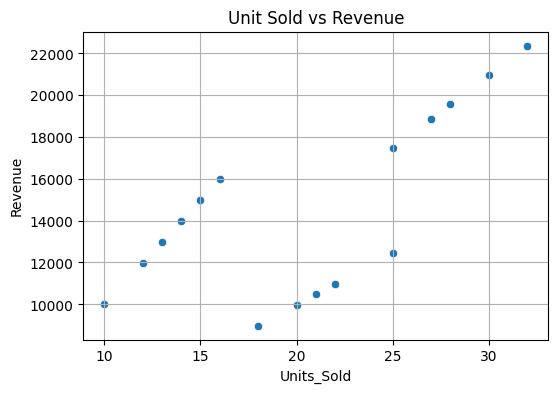

correlation between units sold and revenue: 0.7


In [32]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='Units_Sold',y='Revenue', data=df)
plt.title("Unit Sold vs Revenue")
plt.xlabel('Units_Sold')
plt.ylabel('Revenue')
plt.grid(True)
plt.show()

correlation=df['Units_Sold'].corr(df['Revenue'])
print("correlation between units sold and revenue:" , round(correlation,2))

In [38]:
mean_profit=df['Profit'].mean()
median_profit=df['Profit'].median()
mode_profit=df['Profit'].mode()

print("Mean:",mean_profit)
print("Median:",median_profit)
print("Mode:",mode_profit)

revenue_std=df.groupby('Product')["Revenue"].std()
print(revenue_std)

Mean: 4248.25
Median: 4036.5
Mode: 0     2682
1     2980
2     2990
3     3129
4     3278
5     3588
6     3725
7     3887
8     4186
9     4485
10    4784
11    4975
12    5373
13    5572
14    5970
15    6368
Name: Profit, dtype: int64
Product
Laptop    2158.086653
Phone     1888.594001
Tablet    1291.629475
Name: Revenue, dtype: float64


In [47]:
p_lap=(df['Product']=='Laptop').mean()
p_north=(df['Region']=='North').mean()
p_joint= ((df['Product']=='Laptop')&(df['Region']=='North')) .mean()

p_con= p_joint/p_lap

p_uni=p_lap+p_north-p_joint

print(p_lap)
print(p_north)
print(p_joint)
print(p_con)
print(p_uni)



0.375
0.25
0.125
0.3333333333333333
0.5


/tmp/ipython-input-48-230676289.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  mont_sale=df.resample('M',on='Date')['Revenue'].sum()


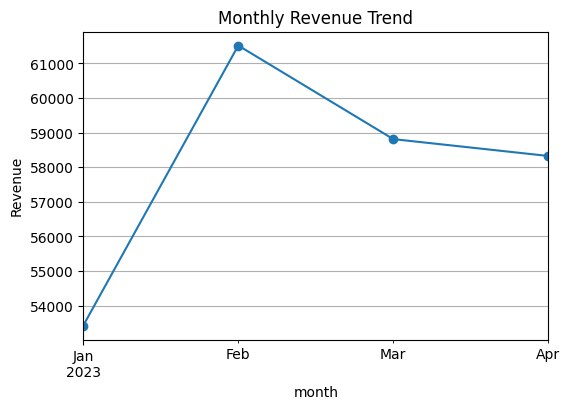

In [48]:
mont_sale=df.resample('M',on='Date')['Revenue'].sum()

plt.figure(figsize=(6,4))
mont_sale.plot(marker='o')
plt.title("Monthly Revenue Trend")
plt.xlabel('month')
plt.ylabel("Revenue")
plt.grid(True)
plt.show()


In [51]:
from scipy.stats import chi2_contingency

con_table=pd.crosstab(df['Sales_Rep'],df['Product'])

chi2,p,dof,expected = chi2_contingency(con_table)

print("Chi Square value:",round(chi2,2))
print("p=value:",round(p,4))

if p<0.05:
  print("This is Significant Relationship")

else:
  print("No Significant Relationship Found")

Chi Square value: 1.87
p=value: 0.9315
No Significant Relationship Found
